In [1]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten,BatchNormalization,Dropout

In [40]:
import zipfile

zip_path = "data.zip"
extract_to = "ImageData"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_to)

print("Done!")

Done!


In [2]:
# generators

train_data = keras.utils.image_dataset_from_directory(
    directory = 'ImageData/test',
    labels = 'inferred',
    label_mode = 'int',
    batch_size = 8,
    image_size = (256,256)
)

# for validation
validation_ds = keras.utils.image_dataset_from_directory(
    directory = 'ImageData/test',
    labels = 'inferred',
    label_mode = 'int',
    batch_size = 8,
    image_size = (256,256)
)

Found 5000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


In [3]:
# Normalise
def process(image,label):
    image = tf.cast(image/255. ,tf.float32)
    return image,label

train_data = train_data.map(process)
validation_ds = validation_ds.map(process)

In [4]:
# Create CNN Model

model = Sequential()

model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(1,activation='sigmoid'))

In [5]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 254, 254, 32)      896       
                                                                 
 batch_normalization (BatchN  (None, 254, 254, 32)     128       
 ormalization)                                                   
                                                                 
 max_pooling2d (MaxPooling2D  (None, 127, 127, 32)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 125, 125, 64)      18496     
                                                                 
 batch_normalization_1 (Batc  (None, 125, 125, 64)     256       
 hNormalization)                                                 
                                                        

In [6]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [7]:
history = model.fit(train_data,epochs=10,validation_data=validation_ds)

Epoch 1/10
625/625 [==============================] - 312s 497ms/step - loss: 3.0798 - accuracy: 0.5464 - val_loss: 0.7285 - val_accuracy: 0.5734
Epoch 2/10
625/625 [==============================] - 297s 475ms/step - loss: 0.7691 - accuracy: 0.5808 - val_loss: 0.6344 - val_accuracy: 0.6600
Epoch 3/10
625/625 [==============================] - 306s 490ms/step - loss: 0.6643 - accuracy: 0.6506 - val_loss: 0.6042 - val_accuracy: 0.6858
Epoch 4/10
625/625 [==============================] - 290s 465ms/step - loss: 0.6113 - accuracy: 0.6894 - val_loss: 0.5634 - val_accuracy: 0.6812
Epoch 5/10
625/625 [==============================] - 351s 562ms/step - loss: 0.5292 - accuracy: 0.7494 - val_loss: 0.4650 - val_accuracy: 0.7868
Epoch 6/10
625/625 [==============================] - 325s 520ms/step - loss: 0.4795 - accuracy: 0.7754 - val_loss: 0.4174 - val_accuracy: 0.8160
Epoch 7/10
625/625 [==============================] - 309s 495ms/step - loss: 0.4441 - accuracy: 0.8014 - val_loss: 0.9491 -

In [8]:
import matplotlib.pyplot as plt

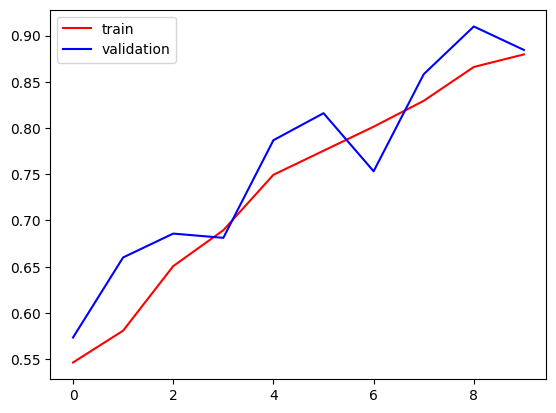

In [9]:
plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

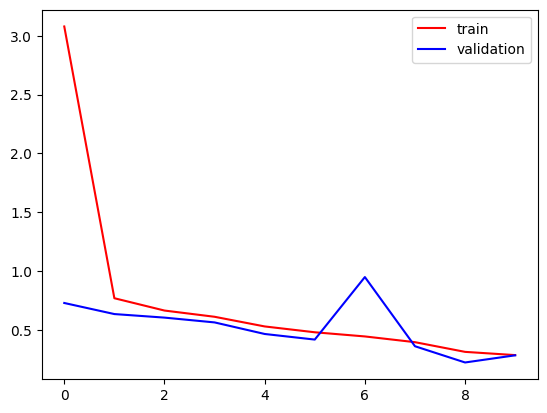

In [10]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

In [ ]:
# Lets test this model for Dog

In [11]:
import cv2

In [12]:
test_img = cv2.imread('dog.jpg')

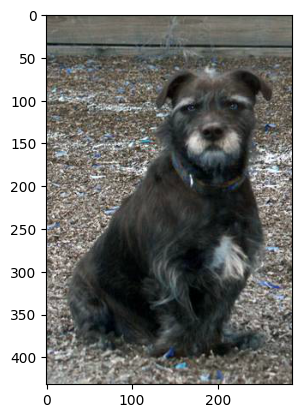

In [13]:
plt.imshow(test_img)

In [14]:
test_img.shape

(432, 287, 3)

In [15]:
test_img = cv2.resize(test_img,(256,256))

In [16]:
test_input = test_img.reshape((1,256,256,3))

In [ ]:
model.predict(test_input)
# class 1 is for Dog - so correct prediction

1/1 [==============================] - 0s 206ms/step


array([[1.]], dtype=float32)

In [ ]:
# Lets test this model for Cat

In [18]:
test_img = cv2.imread('cat.jpg')

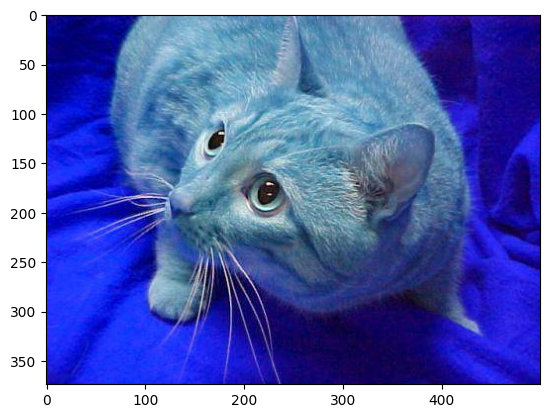

In [19]:
plt.imshow(test_img)

In [20]:
test_img.shape

(374, 500, 3)

In [21]:
test_img = cv2.resize(test_img,(256,256))

In [22]:
test_input = test_img.reshape((1,256,256,3))

In [ ]:
model.predict(test_input)
# class 0 is for Cat - so correct prediction

1/1 [==============================] - 0s 39ms/step


array([[0.]], dtype=float32)